In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel3",
)

In [2]:
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)
len(tasks)

2026-07-08 02:49:59 [info     ] search_called                  provider=search_earthaccess


/root/repos/aereo/.venv/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/root/repos/aereo/components/aereo/builtins/search.py:324: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  size_mb = g.size()


2026-07-08 02:50:06 [info     ] build_tasks_start              assets=3 builder=build_grouped_tasks


/root/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


3

In [3]:
# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=1, use_threads=False, cache=TaskResultCache())

In [ ]:
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts)} artifacts")

(<Figure size 2000x1732.36 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


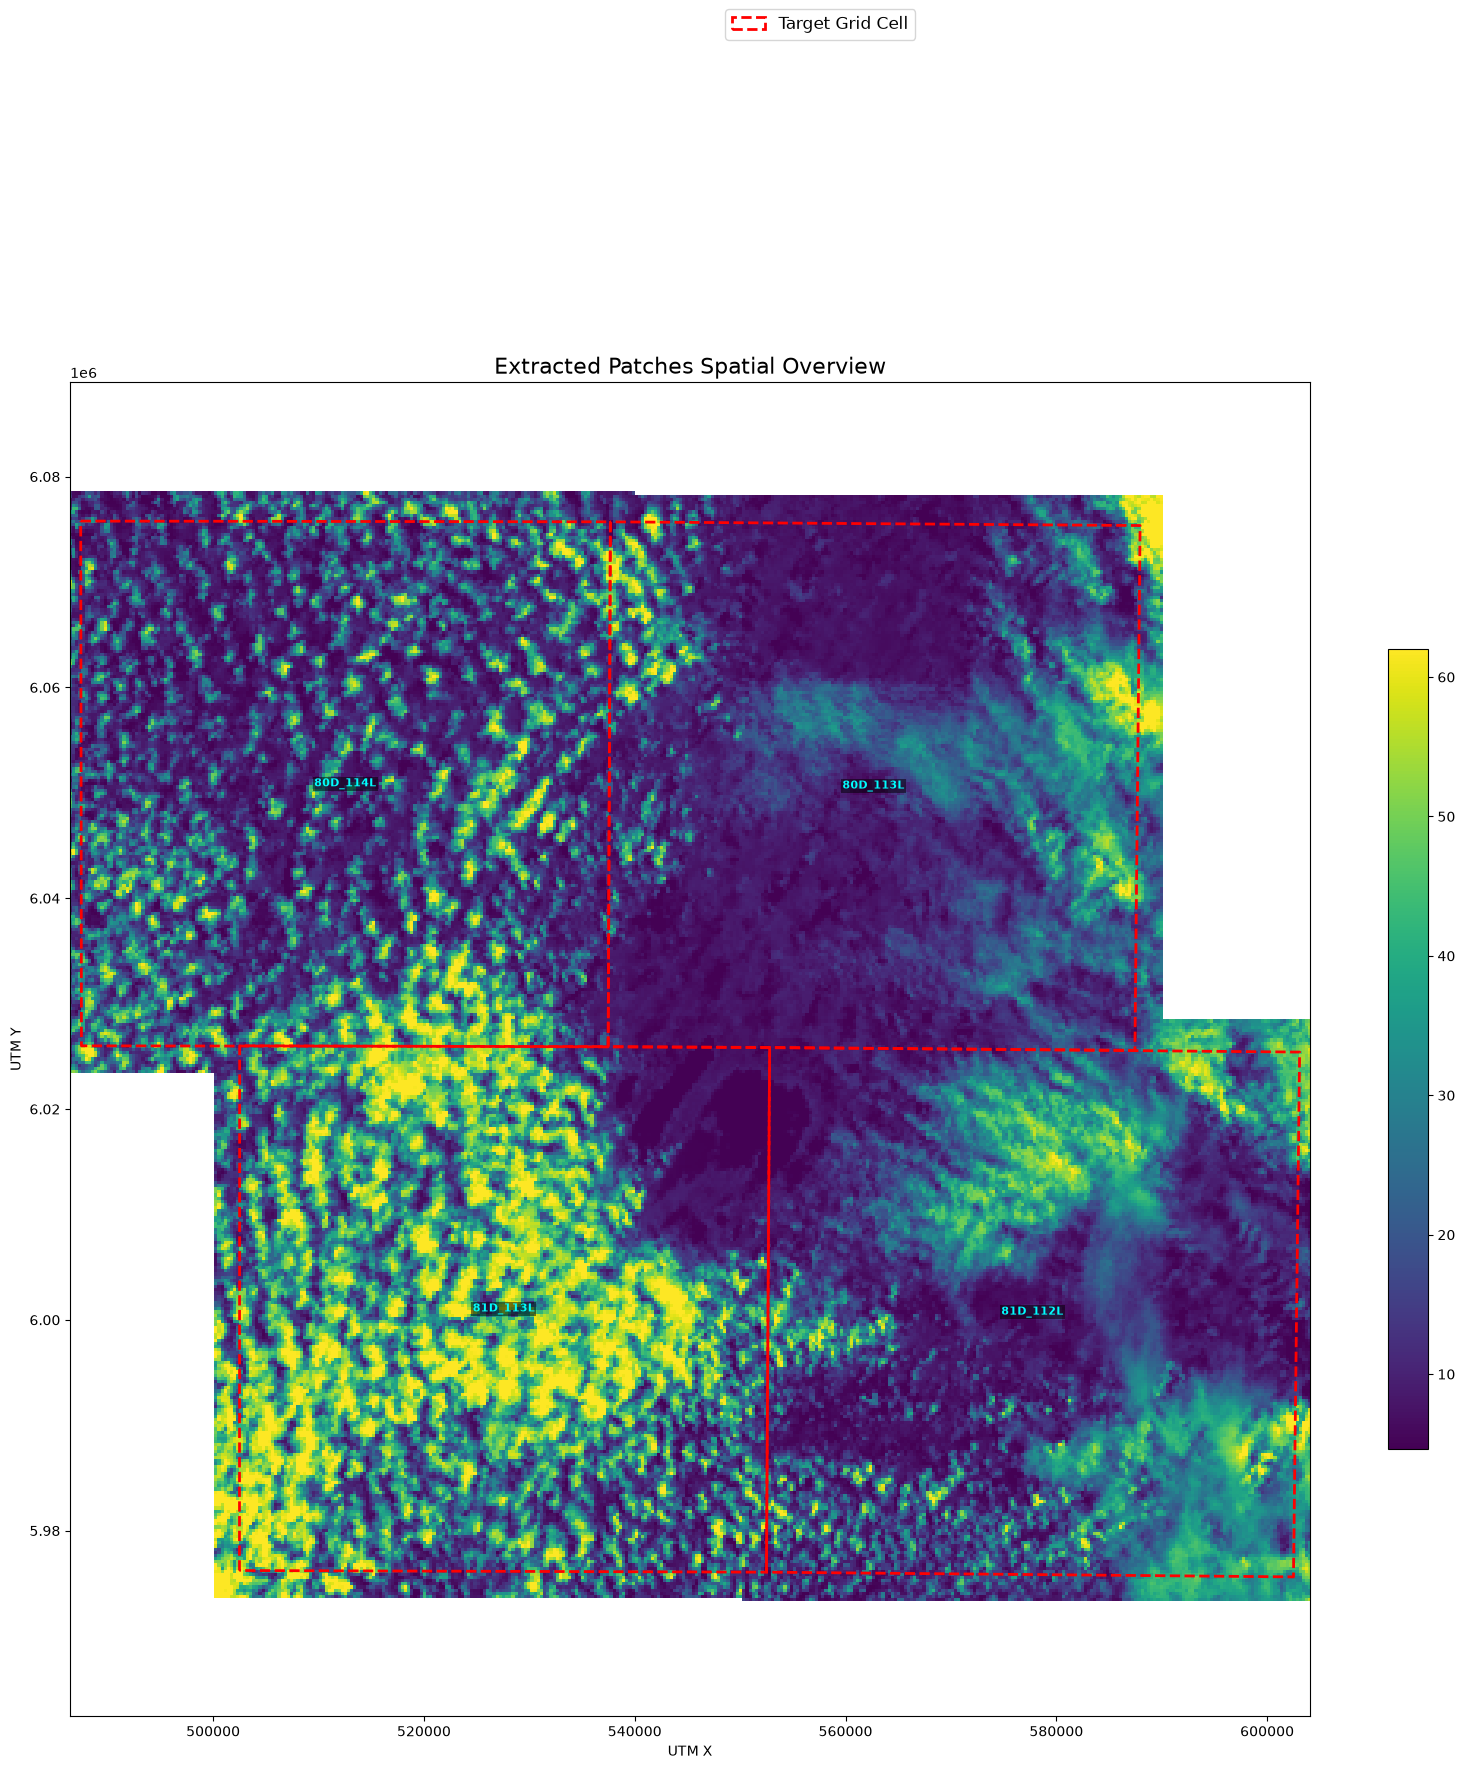

In [5]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, ds_factor=1, stretch="percentile", cmap="viridis")